## Cell 1 — Mount Drive and Install Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

PROJECT_DIR = '/content/drive/MyDrive/IDS_Project'
DATA_DIR    = f'{PROJECT_DIR}/data'
MODEL_DIR   = f'{PROJECT_DIR}/models'
os.makedirs(MODEL_DIR, exist_ok=True)

print('Ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Ready.


## Cell 2 — Load Cleaned Dataset

In [ ]:
CSV_PATH = f'{DATA_DIR}/cicids2017_cleaned.csv'
print(f'Loading {CSV_PATH} ...')

df = pd.read_csv(CSV_PATH, low_memory=False)
df.columns = df.columns.str.strip()
df['Label'] = df['Label'].str.strip()

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Label column unique values: {df["Label"].nunique()}')

Loading /content/drive/MyDrive/IDS_Project/data/cicids2017_cleaned.csv ...


## Cell 3 — EDA: Label Distribution

LABEL DISTRIBUTION
BENIGN                                   2,096,484  (83.12%)  █████████████████████████████████████████
DoS Hulk                                  172,849  ( 6.85%)  ███
DDoS                                      128,016  ( 5.08%)  ██
PortScan                                   90,819  ( 3.60%)  █
DoS GoldenEye                              10,286  ( 0.41%)  
FTP-Patator                                 5,933  ( 0.24%)  
DoS slowloris                               5,385  ( 0.21%)  
DoS Slowhttptest                            5,228  ( 0.21%)  
SSH-Patator                                 3,219  ( 0.13%)  
Bot                                         1,953  ( 0.08%)  
Web Attack � Brute Force                    1,470  ( 0.06%)  
Web Attack � XSS                              652  ( 0.03%)  
Infiltration                                   36  ( 0.00%)  
Web Attack � Sql Injection                     21  ( 0.00%)  
Heartbleed                                     11  ( 0.00%)  


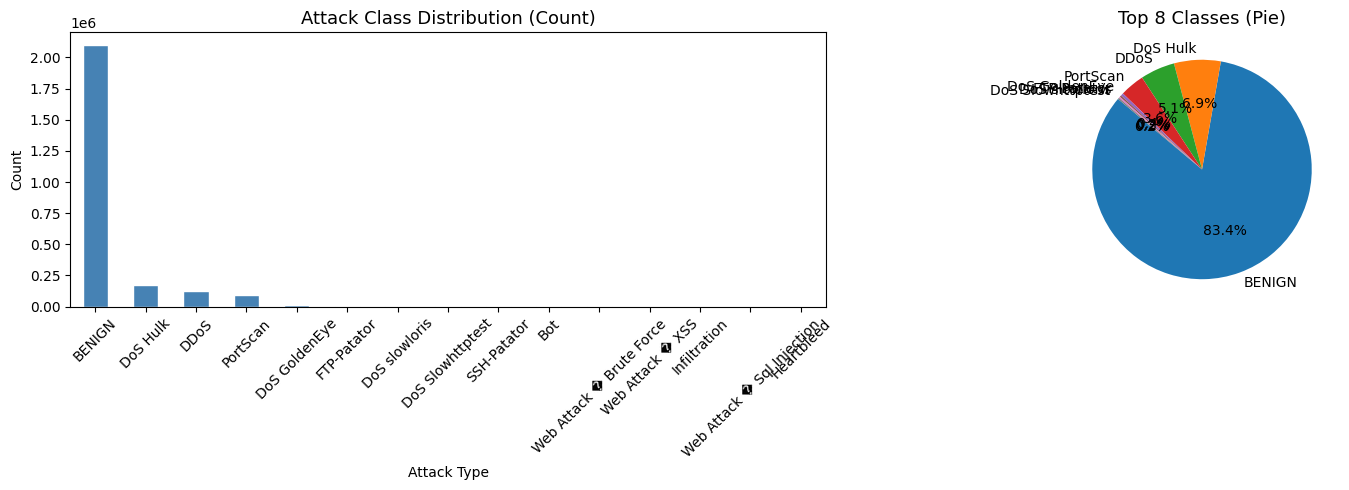

 EDA chart saved.


In [ ]:
label_counts = df['Label'].value_counts()
label_pct    = df['Label'].value_counts(normalize=True) * 100

print('LABEL DISTRIBUTION')
print('='*55)
for label, count in label_counts.items():
    pct = label_pct[label]
    bar = '█' * int(pct / 2)
    print(f'{label:<40} {count:>8,}  ({pct:5.2f}%)  {bar}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Attack Class Distribution (Count)', fontsize=13)
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart (top 8 for readability)
top8 = label_counts.head(8)
axes[1].pie(top8, labels=top8.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Top 8 Classes (Pie)', fontsize=13)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/eda_label_distribution.png', dpi=120)
plt.show()
print('EDA chart saved.')

## Cell 4 — EDA: Feature Correlation Heatmap (Top 20 Features)

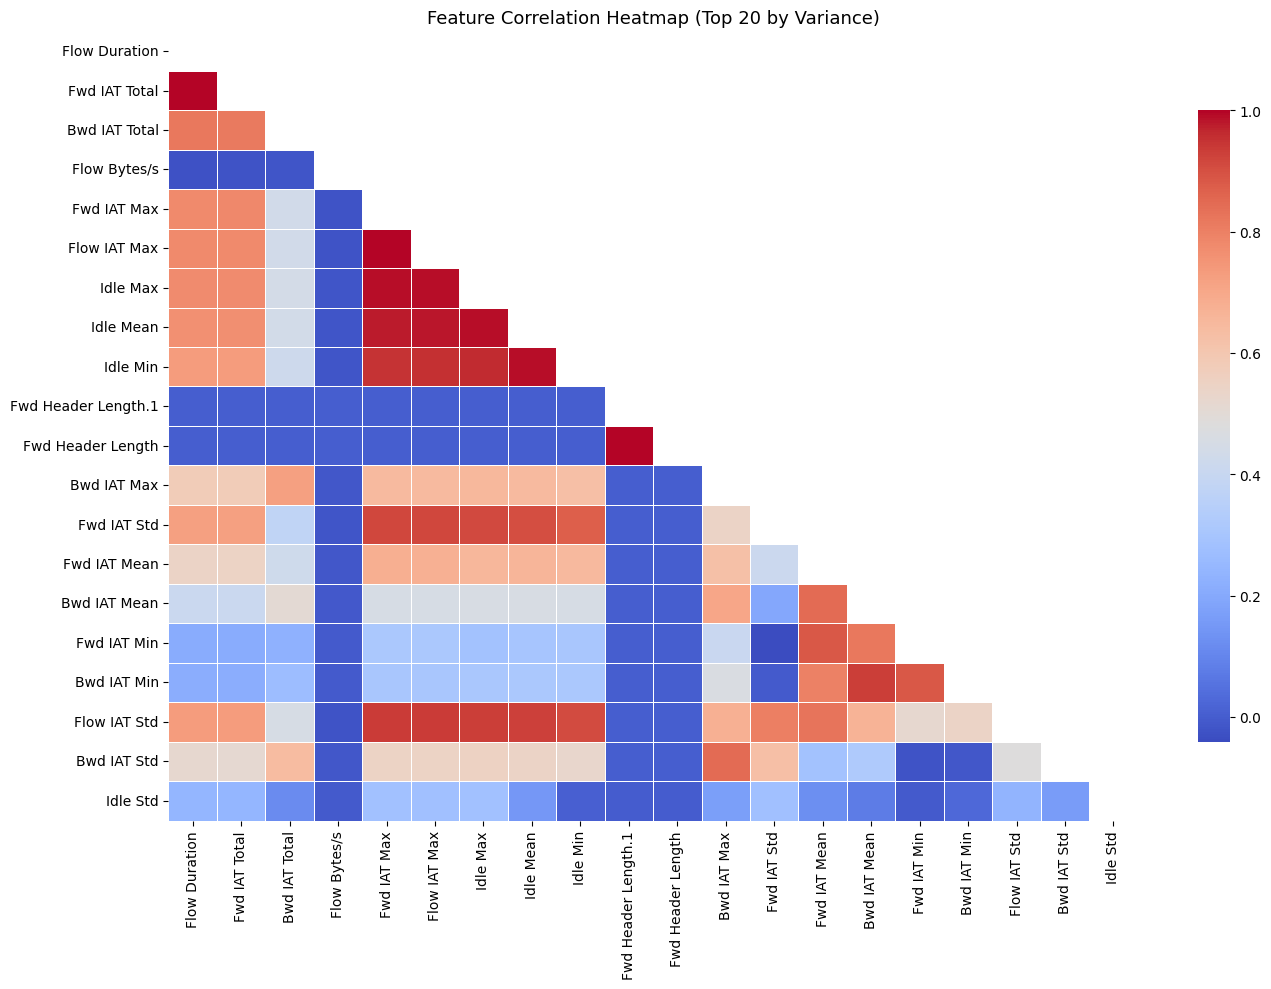

 Heatmap saved.


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

# Use top 20 features by variance for readability
top20 = numeric_df.var().sort_values(ascending=False).head(20).index.tolist()

plt.figure(figsize=(14, 10))
corr = numeric_df[top20].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.5, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap (Top 20 by Variance)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/eda_correlation_heatmap.png', dpi=120)
plt.show()
print('Heatmap saved.')

## Cell 5 — Feature Engineering and Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Binary label: BENIGN=0, ATTACK=1
df['Binary_Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# ── Multi-class label: encode each attack type as integer
le = LabelEncoder()
df['Multi_Label'] = le.fit_transform(df['Label'])

print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i:>2}  to  {cls}')

# ── Save label encoder for use in the Python engine later
joblib.dump(le, f'{MODEL_DIR}/label_encoder.pkl')
print(f'\nlabel_encoder.pkl saved to {MODEL_DIR}')

# ── Drop columns not useful for ML
DROP_COLS = ['Label', 'Binary_Label', 'Multi_Label']
feature_cols = [c for c in df.columns if c not in DROP_COLS]
print(f'\nFeature columns: {len(feature_cols)}')

Label encoding:
   0  to  BENIGN
   1  to  Bot
   2  to  DDoS
   3  to  DoS GoldenEye
   4  to  DoS Hulk
   5  to  DoS Slowhttptest
   6  to  DoS slowloris
   7  to  FTP-Patator
   8  to  Heartbleed
   9  to  Infiltration
  10  to  PortScan
  11  to  SSH-Patator
  12  to  Web Attack � Brute Force
  13  to  Web Attack � Sql Injection
  14  to  Web Attack � XSS

 label_encoder.pkl saved  to  /content/drive/MyDrive/IDS_Project/models

 Feature columns: 78


## Cell 6 — Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df[feature_cols].values
y_binary = df['Binary_Label'].values
y_multi  = df['Multi_Label'].values

# 80% train, 20% test — stratified to keep class ratios
X_train, X_test, yb_train, yb_test, ym_train, ym_test = train_test_split(
    X, y_binary, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')
print(f'Features     : {X_train.shape[1]}')

Training set : 2,017,889 rows
Test set     : 504,473 rows
Features     : 78


## Cell 7 — Handle Class Imbalance with SMOTE (Binary only)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

print('Applying SMOTE + Undersampling combo (RAM-safe)...')
print(f'Before — BENIGN: {(yb_train==0).sum():,}  ATTACK: {(yb_train==1).sum():,}')

# Step 1: SMOTE brings ATTACK up to 50% of BENIGN count
# Step 2: Undersample BENIGN down to match ATTACK  to  final 1:1 ratio
over  = SMOTE(sampling_strategy=0.5, random_state=42)
under = RandomUnderSampler(sampling_strategy=1.0, random_state=42)

pipe = Pipeline([('over', over), ('under', under)])
X_train_bal, yb_train_bal = pipe.fit_resample(X_train, yb_train)

print(f'After  — BENIGN: {(yb_train_bal==0).sum():,}  ATTACK: {(yb_train_bal==1).sum():,}')
print('Done. RAM-safe.')

Applying SMOTE + Undersampling combo (RAM-safe)...
Before — BENIGN: 1,677,187  ATTACK: 340,702
After  — BENIGN: 838,593  ATTACK: 838,593
 Done. RAM-safe.


## Cell 8 — Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
import gc

#  Free original X from RAM before scaling — critical step
del df
gc.collect()
print('Freed original dataframe from RAM.')

scaler = StandardScaler()

# Fit on balanced training data
X_train_scaled      = scaler.fit_transform(X_train_bal)
X_test_scaled       = scaler.transform(X_test)

# Scale original unbalanced train for multi-class
X_train_orig_scaled = scaler.transform(X_train)

# Free unscaled versions — no longer needed
del X_train_bal
gc.collect()

joblib.dump(scaler,       f'{MODEL_DIR}/scaler.pkl')
joblib.dump(feature_cols, f'{MODEL_DIR}/feature_cols.pkl')
print(f'scaler.pkl saved.')
print(f'feature_cols.pkl saved.')

 Freed original dataframe from RAM.
 scaler.pkl saved.
 feature_cols.pkl saved.


## Cell 9 — Train Binary Random Forest (BENIGN vs ATTACK)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import time

print('Training Binary Random Forest...')
start = time.time()

rf_binary = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,           # use all CPU cores
    random_state=42,
    verbose=1
)
rf_binary.fit(X_train_scaled, yb_train_bal)

elapsed = time.time() - start
print(f'\nBinary RF trained in {elapsed:.1f} seconds')

Training Binary Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  4.7min



 Binary RF trained in 611.1 seconds


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 10.2min finished


## Cell 10 — Evaluate Binary Model

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    2.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.3s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    2.2s finished


BINARY MODEL RESULTS (BENIGN vs ATTACK)
Accuracy  : 99.88%
ROC-AUC   : 1.0000

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    419297
      ATTACK       0.99      1.00      1.00     85176

    accuracy                           1.00    504473
   macro avg       1.00      1.00      1.00    504473
weighted avg       1.00      1.00      1.00    504473



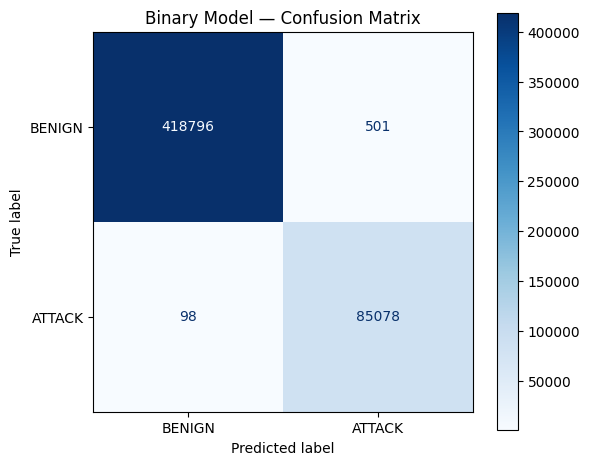

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, ConfusionMatrixDisplay
)

yb_pred = rf_binary.predict(X_test_scaled)
yb_prob = rf_binary.predict_proba(X_test_scaled)[:, 1]

acc    = accuracy_score(yb_test, yb_pred)
roc    = roc_auc_score(yb_test, yb_prob)

print('='*55)
print('BINARY MODEL RESULTS (BENIGN vs ATTACK)')
print('='*55)
print(f'Accuracy  : {acc*100:.2f}%')
print(f'ROC-AUC   : {roc:.4f}')
print()
print(classification_report(yb_test, yb_pred, target_names=['BENIGN', 'ATTACK']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    yb_test, yb_pred,
    display_labels=['BENIGN', 'ATTACK'],
    cmap='Blues', ax=ax
)
ax.set_title('Binary Model — Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/binary_confusion_matrix.png', dpi=120)
plt.show()

## Cell 11 — Train Multi-Class Random Forest (Attack Type Identification)

In [ ]:
print('Training Multi-Class Random Forest...')
start = time.time()

rf_multi = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # handles imbalance without SMOTE for multi-class
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_multi.fit(X_train_orig_scaled, ym_train)

elapsed = time.time() - start
print(f'\nMulti-Class RF trained in {elapsed:.1f} seconds')

Training Multi-Class Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  5.6min



 Multi-Class RF trained in 698.6 seconds


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 11.6min finished


## Cell 12 — Evaluate Multi-Class Model

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.9s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    6.5s finished


MULTI-CLASS MODEL RESULTS
Accuracy : 99.48%

                            precision    recall  f1-score   support

                    BENIGN       1.00      0.99      1.00    419297
                       Bot       0.18      0.99      0.30       396
                      DDoS       1.00      1.00      1.00     25632
             DoS GoldenEye       0.99      1.00      0.99      2003
                  DoS Hulk       0.99      1.00      0.99     34648
          DoS Slowhttptest       0.98      1.00      0.99       970
             DoS slowloris       1.00      0.99      1.00      1107
               FTP-Patator       1.00      1.00      1.00      1136
              Infiltration       1.00      0.67      0.80         6
                  PortScan       0.99      1.00      0.99     18211
               SSH-Patator       1.00      1.00      1.00       640
  Web Attack � Brute Force       0.80      0.63      0.70       310
Web Attack � Sql Injection       0.00      0.00      0.00         3
  

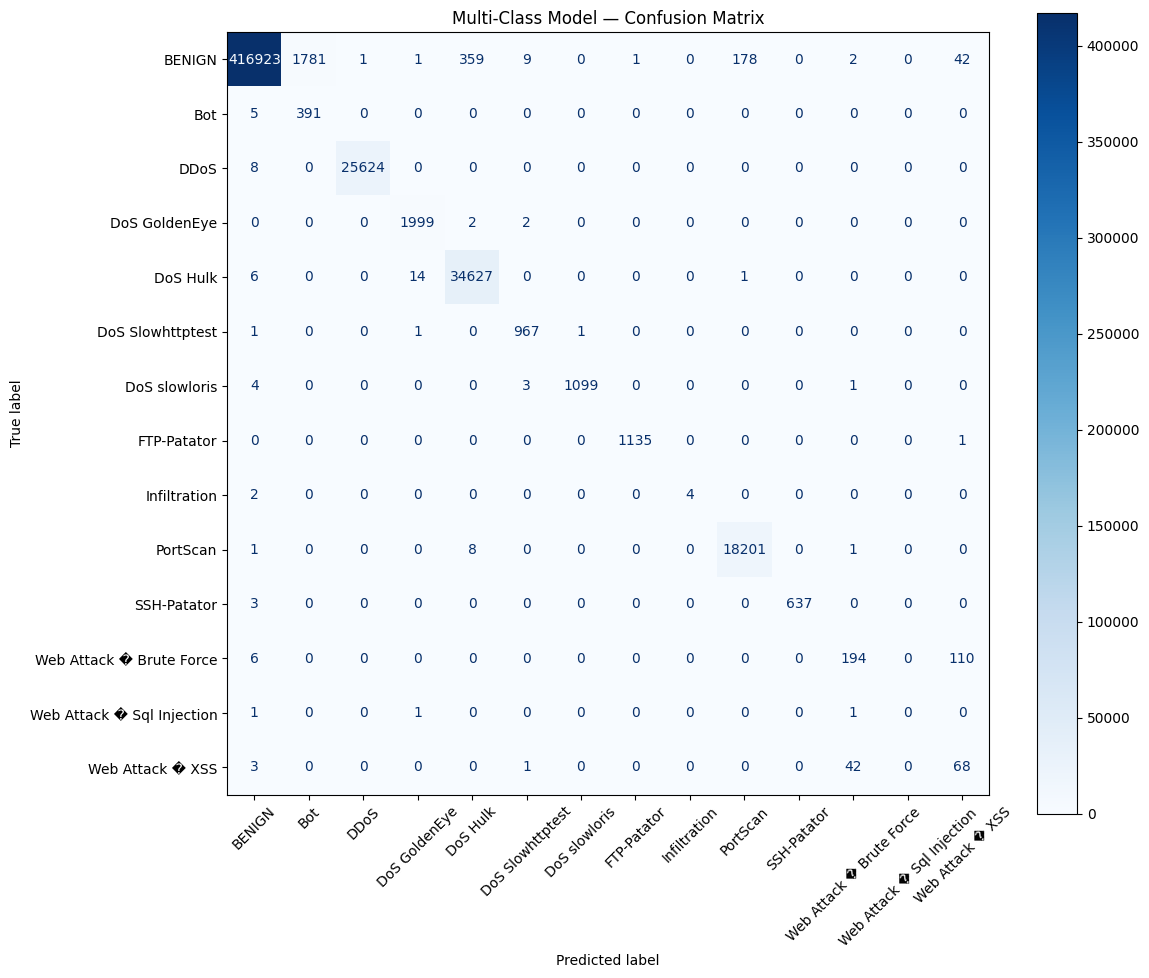


 Missing class was: {'Heartbleed'}
   (too few samples to appear in 20% test split — normal for rare attacks)


In [ ]:
import numpy as np

ym_pred = rf_multi.predict(X_test_scaled)
acc_m = accuracy_score(ym_test, ym_pred)

print('='*55)
print('MULTI-CLASS MODEL RESULTS')
print('='*55)
print(f'Accuracy : {acc_m*100:.2f}%')
print()

#  FIXED: only use classes actually present in test set
classes_in_test = np.unique(ym_test)
class_names     = le.inverse_transform(classes_in_test)

print(classification_report(
    ym_test, ym_pred,
    labels=classes_in_test,        #  tell it which labels to expect
    target_names=class_names       #  matching names only
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    ym_test, ym_pred,
    labels=classes_in_test,        #  same fix here
    display_labels=class_names,
    cmap='Blues', ax=ax,
    xticks_rotation=45
)
ax.set_title('Multi-Class Model — Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/multiclass_confusion_matrix.png', dpi=120)
plt.show()

print(f'\nMissing class was: {set(le.classes_) - set(class_names)}')
print('   (too few samples to appear in 20% test split — normal for rare attacks)')

## Cell 13 — Feature Importance (Top 20)

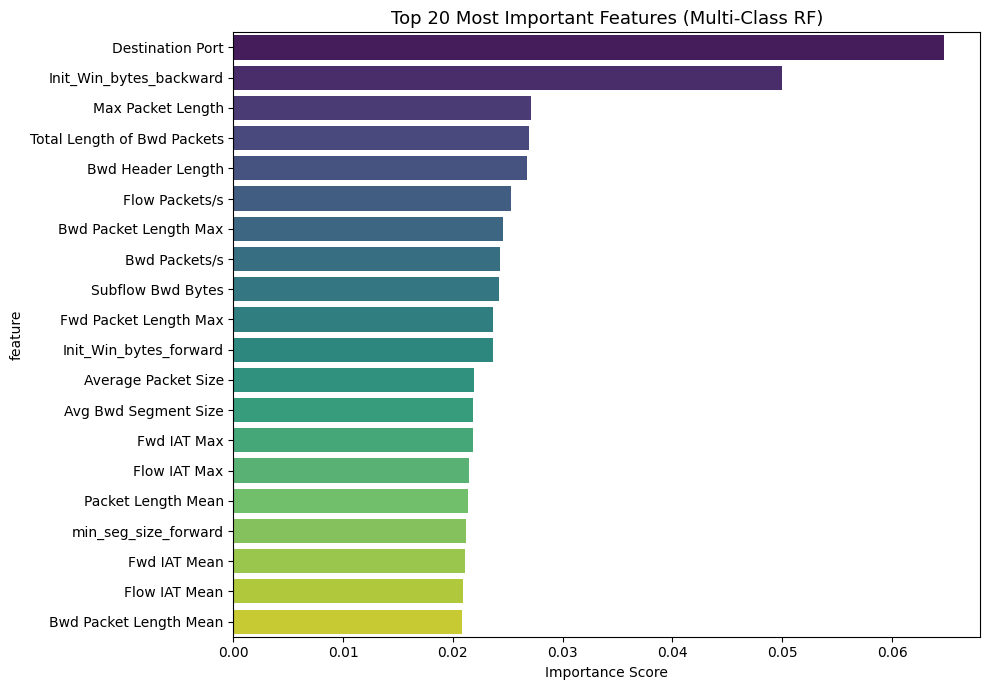

Top 10 features:
  Destination Port                              0.0648
  Init_Win_bytes_backward                       0.0500
  Max Packet Length                             0.0271
  Total Length of Bwd Packets                   0.0270
  Bwd Header Length                             0.0268
  Flow Packets/s                                0.0253
  Bwd Packet Length Max                         0.0246
  Bwd Packets/s                                 0.0242
  Subflow Bwd Bytes                             0.0242
  Fwd Packet Length Max                         0.0237


In [ ]:
importances = rf_multi.feature_importances_
feat_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Most Important Features (Multi-Class RF)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/feature_importance.png', dpi=120)
plt.show()

print('Top 10 features:')
for _, row in feat_df.head(10).iterrows():
    print(f'  {row["feature"]:<45} {row["importance"]:.4f}')

## Cell 14 — Save Models as .pkl Files

In [ ]:
# Save both models
binary_path = f'{MODEL_DIR}/ids_binary_model.pkl'
multi_path  = f'{MODEL_DIR}/ids_multiclass_model.pkl'

joblib.dump(rf_binary, binary_path)
joblib.dump(rf_multi,  multi_path)

# Confirm sizes
for path in [binary_path, multi_path,
             f'{MODEL_DIR}/scaler.pkl',
             f'{MODEL_DIR}/label_encoder.pkl',
             f'{MODEL_DIR}/feature_cols.pkl']:
    size_mb = os.path.getsize(path) / (1024*1024)
    print(f'  {os.path.basename(path):<35} {size_mb:.1f} MB')

print(f'\nAll models saved to {MODEL_DIR}')

   ids_binary_model.pkl                18.0 MB
   ids_multiclass_model.pkl            52.1 MB
   scaler.pkl                          0.0 MB
   label_encoder.pkl                   0.0 MB
   feature_cols.pkl                    0.0 MB

 All models saved to /content/drive/MyDrive/IDS_Project/models


## Cell 15 — Phase 2 Summary Report

In [ ]:
print('='*55)
print('  PHASE 2 COMPLETE SUMMARY REPORT')
print('='*55)
#  FIXED: df was deleted to free RAM, use saved values instead
print(f'  Features used            : {len(feature_cols)}')
print(f'  Attack classes           : {len(le.classes_)}')
print()
print(f'  Binary Model Accuracy    : {acc*100:.2f}%')
print(f'  Binary Model ROC-AUC     : {roc:.4f}')
print(f'  Multi-Class Accuracy     : {acc_m*100:.2f}%')
print()
print('  Saved files:')
print('    ids_binary_model.pkl')
print('    ids_multiclass_model.pkl')
print('    scaler.pkl')
print('    label_encoder.pkl')
print('    feature_cols.pkl')
print()
print('  Next  to  Phase 3: Next.js Frontend + FastAPI Backend')
print('='*55)

  PHASE 2 COMPLETE SUMMARY REPORT
  Features used            : 78
  Attack classes           : 15

  Binary Model Accuracy    : 99.88%
  Binary Model ROC-AUC     : 1.0000
  Multi-Class Accuracy     : 99.48%

  Saved files:
     ids_binary_model.pkl
     ids_multiclass_model.pkl
     scaler.pkl
     label_encoder.pkl
     feature_cols.pkl

  Next  to  Phase 3: Next.js Frontend + FastAPI Backend


In [ ]:
import joblib, numpy as np

MODEL_DIR = '/content/drive/MyDrive/IDS_Project/models'

binary_model = joblib.load(f'{MODEL_DIR}/ids_binary_model.pkl')
multi_model  = joblib.load(f'{MODEL_DIR}/ids_multiclass_model.pkl')
scaler       = joblib.load(f'{MODEL_DIR}/scaler.pkl')
le           = joblib.load(f'{MODEL_DIR}/label_encoder.pkl')
feature_cols = joblib.load(f'{MODEL_DIR}/feature_cols.pkl')

print('All models loaded.')

 All models loaded.


In [ ]:
# ── TEST 1: 5 BENIGN samples
print('='*65)
print('TEST 1 — Real BENIGN samples from test set')
print('='*65)

benign_idx = np.where(yb_test == 0)[0][:5]
X_benign   = X_test_scaled[benign_idx]

b_preds = binary_model.predict(X_benign)
b_probs = binary_model.predict_proba(X_benign)

print(f'\n{"#":<5} {"True":<10} {"Predicted":<10} {"BENIGN conf":>12} {"ATTACK conf":>12} {"Result"}')
print('-'*65)
for i in range(5):
    true_lbl = 'BENIGN'
    pred_lbl = 'ATTACK' if b_preds[i] == 1 else 'BENIGN'
    match    = 'OK' if b_preds[i] == 0 else 'NO'
    print(f'{i+1:<5} {true_lbl:<10} {pred_lbl:<10} {b_probs[i][0]*100:>11.1f}% {b_probs[i][1]*100:>11.1f}%  {match}')

TEST 1 — Real BENIGN samples from test set

#     True       Predicted   BENIGN conf  ATTACK conf Result
-----------------------------------------------------------------
1     BENIGN     BENIGN           100.0%         0.0%  
2     BENIGN     BENIGN           100.0%         0.0%  
3     BENIGN     BENIGN           100.0%         0.0%  
4     BENIGN     BENIGN           100.0%         0.0%  
5     BENIGN     BENIGN           100.0%         0.0%  


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


In [ ]:
# ── TEST 2: 5 ATTACK samples (real rows)
print('\n' + '='*65)
print('TEST 2 — Real ATTACK samples from test set')
print('='*65)

attack_idx = np.where(yb_test == 1)[0][:5]
X_attack   = X_test_scaled[attack_idx]
y_attack_m = ym_test[attack_idx]

b_preds2 = binary_model.predict(X_attack)
b_probs2 = binary_model.predict_proba(X_attack)
m_preds2 = multi_model.predict(X_attack)

true_attack_labels = le.inverse_transform(y_attack_m)
pred_attack_labels = le.inverse_transform(m_preds2)

print(f'\n{"#":<5} {"True Attack Type":<30} {"Predicted Type":<30} {"Conf":>8} {"Result"}')
print('-'*80)
for i in range(5):
    true_lbl = true_attack_labels[i]
    pred_lbl = pred_attack_labels[i]
    conf     = b_probs2[i][1] * 100
    match    = 'OK' if true_lbl == pred_lbl else 'NO'
    print(f'{i+1:<5} {true_lbl:<30} {pred_lbl:<30} {conf:>7.1f}%  {match}')


TEST 2 — Real ATTACK samples from test set

#     True Attack Type               Predicted Type                     Conf Result
--------------------------------------------------------------------------------
1     DoS Hulk                       DoS Hulk                         100.0%  
2     DDoS                           DDoS                             100.0%  
3     DDoS                           DDoS                             100.0%  
4     PortScan                       PortScan                          99.7%  
5     DoS Hulk                       DoS Hulk                         100.0%  


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


In [ ]:
# ── TEST 3: Mixed batch — model must sort them correctly
print('\n' + '='*65)
print('TEST 3 — Mixed batch (BENIGN + ATTACK together)')
print('='*65)

# Pick 3 benign + 3 attack
b_idx = np.where(yb_test == 0)[0][:3]
a_idx = np.where(yb_test == 1)[0][:3]
mixed_idx = np.concatenate([b_idx, a_idx])

np.random.shuffle(mixed_idx)  # shuffle so model doesn't see a pattern

X_mixed  = X_test_scaled[mixed_idx]
yb_mixed = yb_test[mixed_idx]
ym_mixed = ym_test[mixed_idx]

b_preds3 = binary_model.predict(X_mixed)
m_preds3 = multi_model.predict(X_mixed)
true_labels3 = le.inverse_transform(ym_mixed)
pred_labels3 = le.inverse_transform(m_preds3)

print(f'\n{"#":<5} {"True Label":<30} {"Predicted":<30} {"Binary":>8} {"Result"}')
print('-'*80)
for i in range(6):
    true_lbl = true_labels3[i]
    pred_lbl = pred_labels3[i]
    binary   = 'ATTACK' if b_preds3[i] == 1 else 'BENIGN'
    match    = 'OK' if true_lbl == pred_lbl else 'NO'
    print(f'{i+1:<5} {true_lbl:<30} {pred_lbl:<30} {binary:>8}  {match}')

# Summary
correct = sum(true_labels3[i] == pred_labels3[i] for i in range(6))
print(f'\n  Correct: {correct}/6   to   {correct/6*100:.0f}% on this batch')


TEST 3 — Mixed batch (BENIGN + ATTACK together)

#     True Label                     Predicted                        Binary Result
--------------------------------------------------------------------------------
1     BENIGN                         BENIGN                           BENIGN  
2     DDoS                           DDoS                           ATTACK  
3     DDoS                           DDoS                           ATTACK  
4     BENIGN                         BENIGN                           BENIGN  
5     DoS Hulk                       DoS Hulk                       ATTACK  
6     BENIGN                         BENIGN                           BENIGN  

  Correct: 6/6   to   100% on this batch


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


In [ ]:
# ── Final summary
print('\n' + '='*65)
print('  MODEL VALIDATION SUMMARY')
print('='*65)
print(f'  Binary Model Accuracy    : {acc*100:.2f}%')
print(f'  Binary Model ROC-AUC     : {roc:.4f}')
print(f'  Multi-Class Accuracy     : {acc_m*100:.2f}%')
print()
print('  Saved .pkl files:')
import os
for f in ['ids_binary_model.pkl','ids_multiclass_model.pkl',
          'scaler.pkl','label_encoder.pkl','feature_cols.pkl']:
    size = os.path.getsize(f'{MODEL_DIR}/{f}') / (1024*1024)
    print(f'    {f:<35} {size:.1f} MB')
print()
print('='*65)


  MODEL VALIDATION SUMMARY
  Binary Model Accuracy    : 99.88%
  Binary Model ROC-AUC     : 1.0000
  Multi-Class Accuracy     : 99.48%

  Saved .pkl files:
     ids_binary_model.pkl                18.0 MB
     ids_multiclass_model.pkl            52.1 MB
     scaler.pkl                          0.0 MB
     label_encoder.pkl                   0.0 MB
     feature_cols.pkl                    0.0 MB

   Phase 2 complete! Models validated and ready.
  🚀 Next  to  Phase 3: Next.js Frontend + FastAPI Backend
